# Baseline Model Evaluation

The code in this notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from baseline_utils import (load_data, 
plot_baseline_distributions, plot_accuracy_latency_scatter)

In [3]:
df = load_data()

[read_baseline_results] Loaded 383 rows from baseline_summary.csv


In [4]:
df.head(6)

,dataset,model,seed,n_train,n_test,series_length,n_classes,total_time,peak_memory_mb,accuracy,f1_macro,f1_weighted,status,error_msg
8,ACSF1,lr_classifier,42,100,100,1460,10,0.637880,7.995392,0.620000,0.613832,0.613832,ok,NaN
9,ACSF1,rf_classifier,42,100,100,1460,10,0.324914,6.160384,0.780000,0.780675,0.780675,ok,NaN
10,ACSF1,dtw_1nn,42,100,100,1460,10,35.280366,0.065536,0.640000,0.629317,0.629317,ok,NaN
11,Adiac,lr_classifier,42,390,391,176,37,0.162355,0.114688,0.736573,0.707151,0.718992,ok,NaN
12,Adiac,rf_classifier,42,390,391,176,37,0.414555,43.024384,0.636829,0.610232,0.618995,ok,NaN
13,Adiac,dtw_1nn,42,390,391,176,37,5.169159,-102.645760,0.603581,0.587314,0.590383,ok,NaN


In [5]:
df.pivot(index="dataset", columns="model", values="accuracy").reset_index(drop=True)
metric_cols = {
    "DTW": "dtw_1nn",
    "LR": "lr_classifier",
    "RF": "rf_classifier"           
               }

In [6]:
df.pivot(index="dataset", columns="model", values="accuracy").reset_index(drop=True).max()

model
dtw_1nn          1.0
lr_classifier    1.0
rf_classifier    1.0
dtype: float64

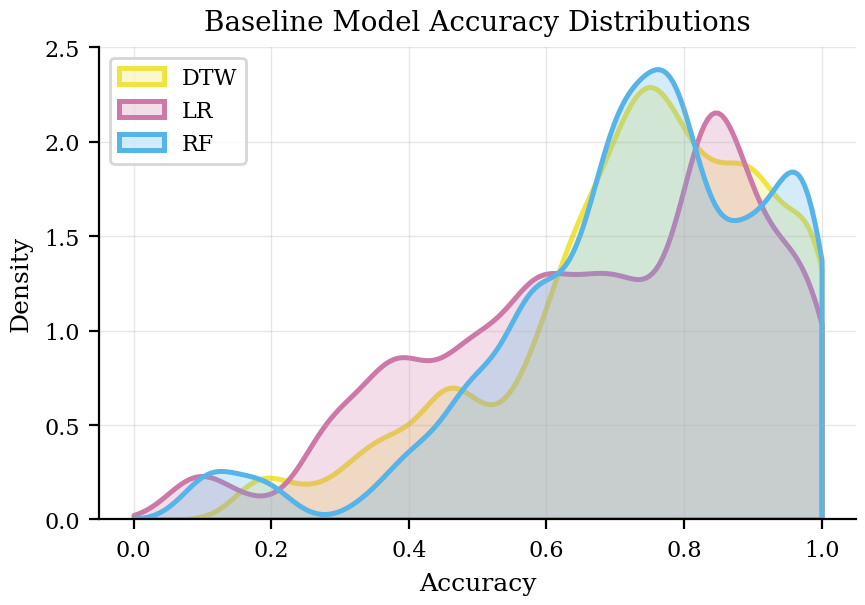

[plot_baseline_distributions] Saved -> figures/baseline_accuracy_distributions.png


'figures/baseline_accuracy_distributions.png'

In [7]:
plot_baseline_distributions(
    df=df.pivot(index="dataset", columns="model", values="accuracy").reset_index(drop=True),
    metric_cols=metric_cols,
    title="Baseline Model Accuracy Distributions",
    xlabel="Accuracy",
    filename="baseline_accuracy_distributions.png",
    clip_range=(0, 1)
)


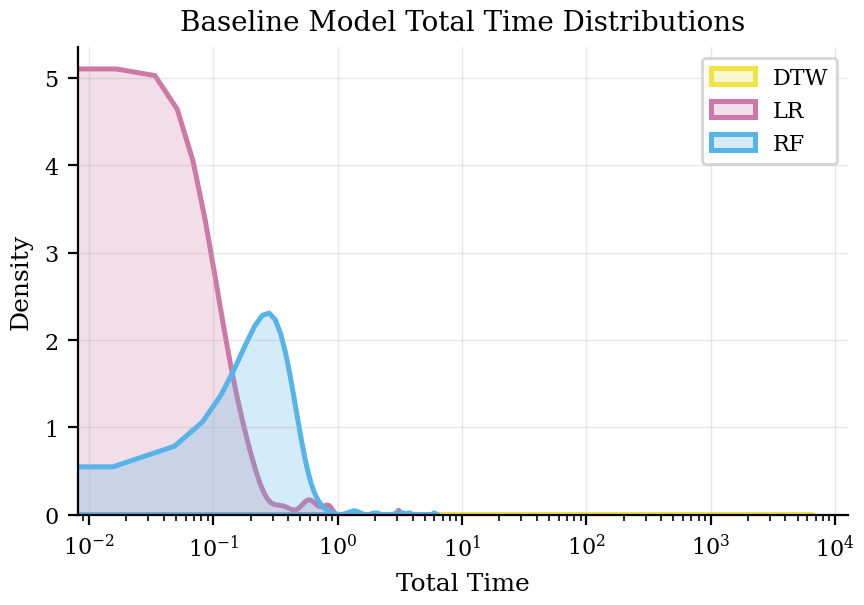

[plot_baseline_distributions] Saved -> figures/baseline_total_time_distributions.png


'figures/baseline_total_time_distributions.png'

In [8]:
plot_baseline_distributions(
    df=df.pivot(index="dataset", columns="model", values="total_time").reset_index(drop=True),
    metric_cols=metric_cols,
    title="Baseline Model Total Time Distributions",
    xlabel="Total Time",
    filename="baseline_total_time_distributions.png",
    use_log_scale=True
)

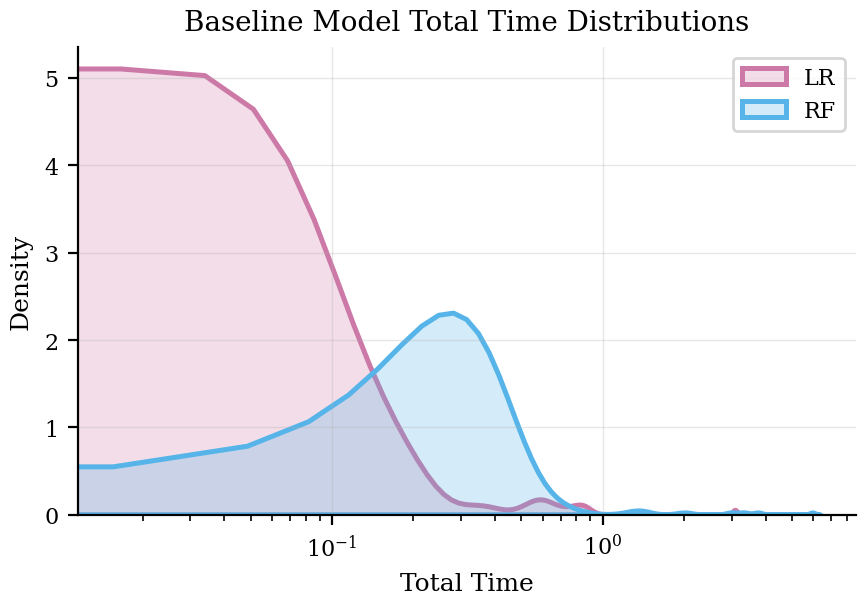

[plot_baseline_distributions] Saved -> figures/baseline_total_time_distributions.png


'figures/baseline_total_time_distributions.png'

In [9]:
plot_baseline_distributions(
    df=df.pivot(index="dataset", columns="model", values="total_time").reset_index(drop=True),
    metric_cols = {"LR": "lr_classifier",
               "RF": "rf_classifier",
               },
    title="Baseline Model Total Time Distributions",
    xlabel="Total Time",
    filename="baseline_total_time_distributions.png",
    use_log_scale=True
)

<Axes: ylabel='Frequency'>

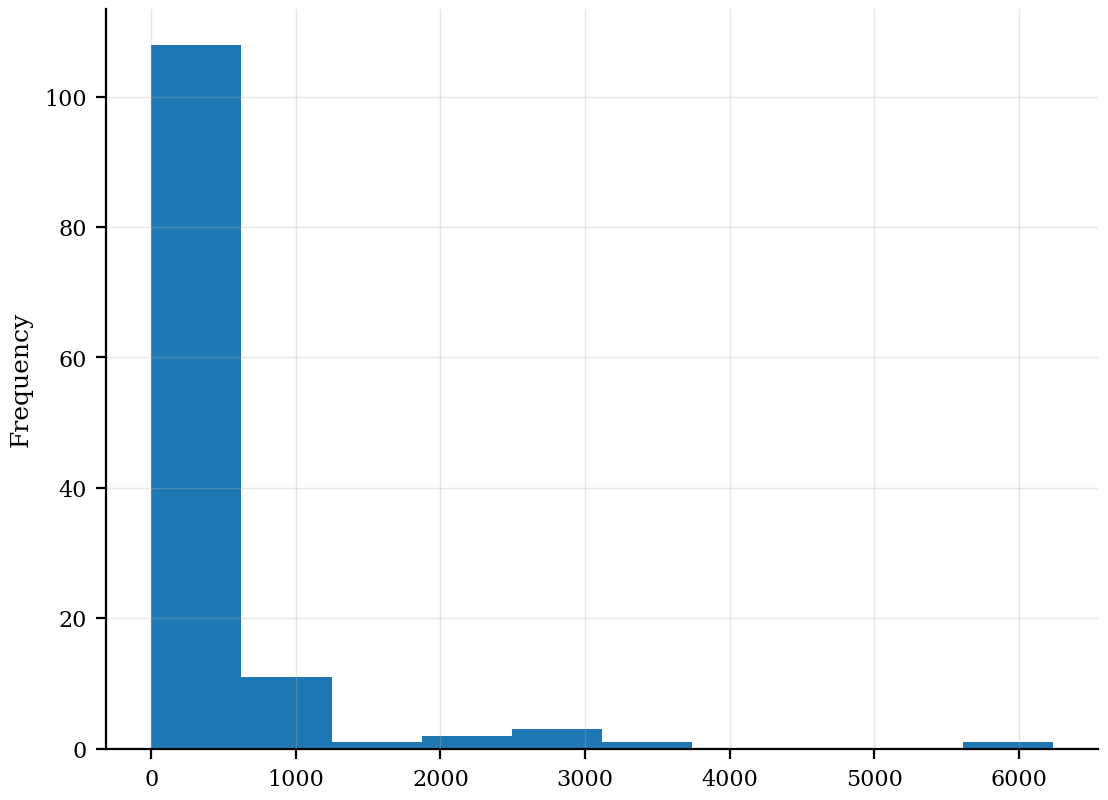

In [10]:
df.pivot(index="dataset", columns="model", values="total_time").reset_index(drop=True)["dtw_1nn"].plot.hist(bins=10)

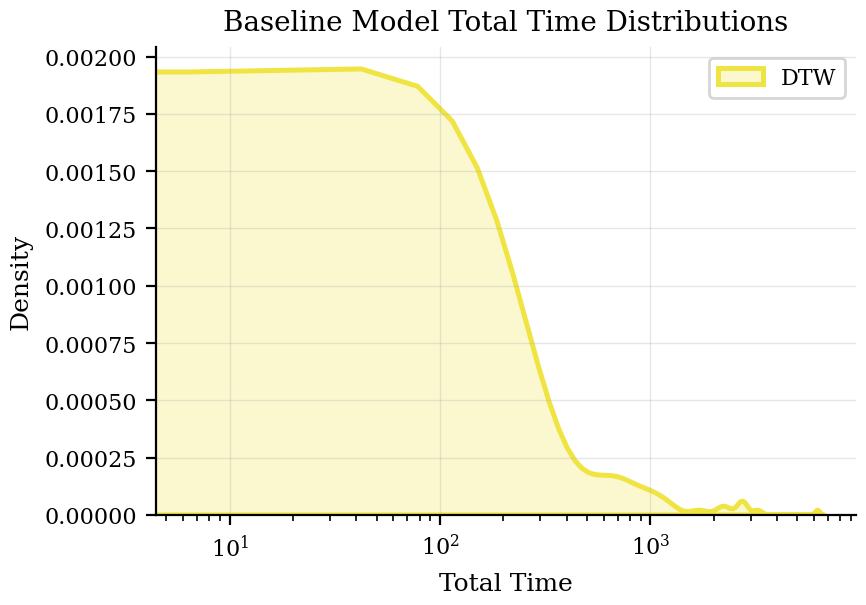

[plot_baseline_distributions] Saved -> figures/baseline_total_time_distributions.png


'figures/baseline_total_time_distributions.png'

In [11]:
plot_baseline_distributions(
    df=df.pivot(index="dataset", columns="model", values="total_time").reset_index(drop=True),
    metric_cols= {
               "DTW": "dtw_1nn"
               },
    title="Baseline Model Total Time Distributions",
    xlabel="Total Time",
    filename="baseline_total_time_distributions.png",
    use_log_scale=True
)

In [12]:
df.pivot(index="dataset", columns="model", values="total_time").reset_index(drop=True).describe()

model,dtw_1nn,lr_classifier,rf_classifier
count,127.000000,128.000000,128.000000
mean,312.891084,0.103139,0.441900
std,810.551885,0.310986,0.714742
min,0.044314,0.002895,0.189296
25%,0.835719,0.006382,0.216350
50%,11.275191,0.014969,0.289809
75%,185.207618,0.076767,0.363851
max,6237.095148,3.095124,5.986368


In [13]:
df.pivot(index="dataset", columns="model", values="accuracy").reset_index(drop=True).describe()

model,dtw_1nn,lr_classifier,rf_classifier
count,127.000000,128.000000,128.000000
mean,0.732573,0.680809,0.730936
std,0.193492,0.228295,0.197393
min,0.176923,0.081731,0.100962
25%,0.637002,0.511796,0.631621
50%,0.756098,0.719881,0.759124
75%,0.881513,0.853611,0.881887
max,1.000000,1.000000,1.000000


In [14]:
df.pivot(index="dataset", columns="model", values="f1_macro").reset_index(drop=True).describe()

model,dtw_1nn,lr_classifier,rf_classifier
count,127.000000,128.000000,128.000000
mean,0.713065,0.662608,0.702631
std,0.200781,0.234223,0.210199
min,0.130502,0.037163,0.035413
25%,0.587826,0.490645,0.571145
50%,0.744246,0.699718,0.725624
75%,0.869210,0.850447,0.868110
max,1.000000,1.000000,1.000000


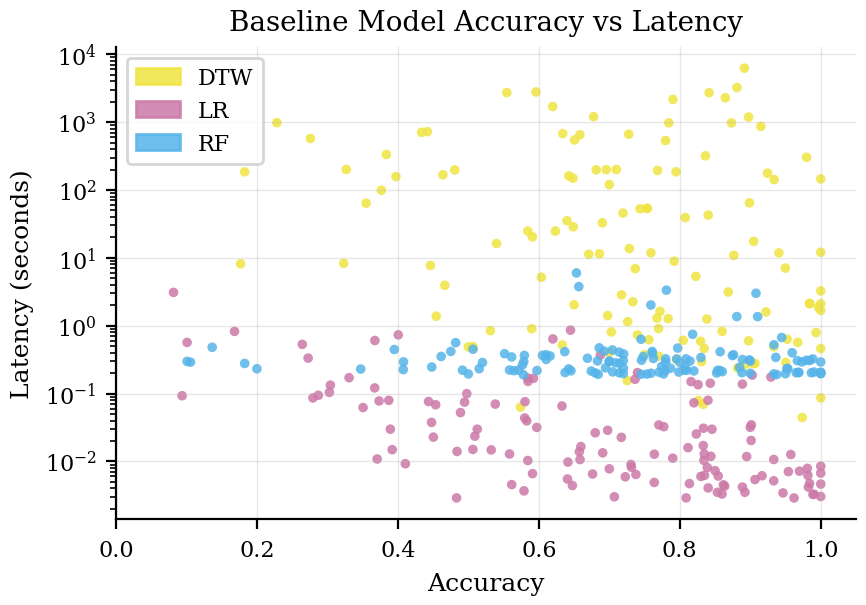

[plot_accuracy_latency_scatter] Saved -> figures/baseline_accuracy_vs_latency.png


'figures/baseline_accuracy_vs_latency.png'

In [15]:
plot_accuracy_latency_scatter(df)